In [2]:
import kagglehub
adityajn105_flickr8k_path = kagglehub.dataset_download('adityajn105/flickr8k')

print('Data source import complete.')


Data source import complete.


#Load Dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/


#Show Samples

Displaying 5 sample images with captions:


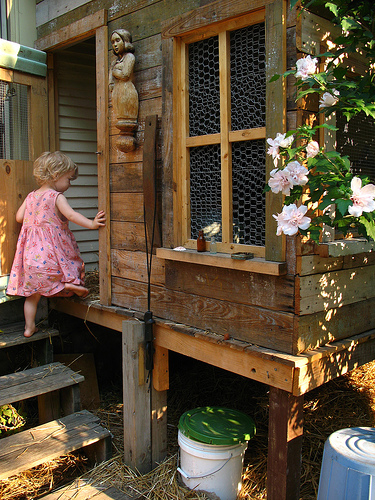

Captions for 1000268201_693b08cb0e.jpg:
- A child in a pink dress is climbing up a set of stairs in an entry way .
- A girl going into a wooden building .
- A little girl climbing into a wooden playhouse .
- A little girl climbing the stairs to her playhouse .
- A little girl in a pink dress going into a wooden cabin .


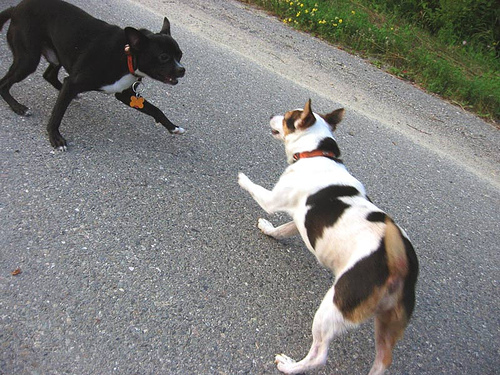

Captions for 1001773457_577c3a7d70.jpg:
- A black dog and a spotted dog are fighting
- A black dog and a tri-colored dog playing with each other on the road .
- A black dog and a white dog with brown spots are staring at each other in the street .
- Two dogs of different breeds looking at each other on the road .
- Two dogs on pavement moving toward each other .


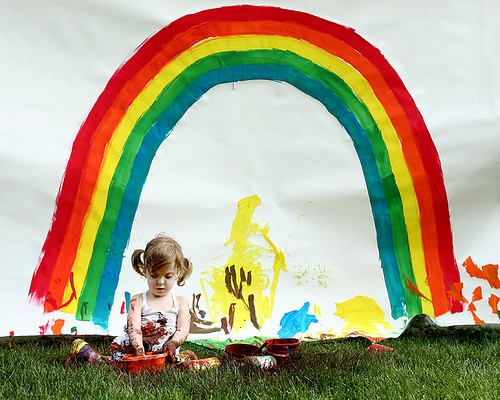

Captions for 1002674143_1b742ab4b8.jpg:
- A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
- A little girl is sitting in front of a large painted rainbow .
- A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .
- There is a girl with pigtails sitting in front of a rainbow painting .
- Young girl with pigtails painting outside in the grass .


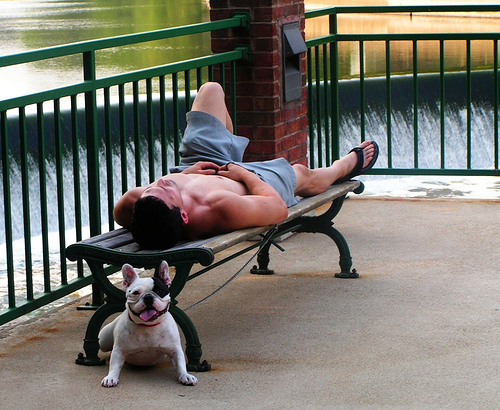

Captions for 1003163366_44323f5815.jpg:
- A man lays on a bench while his dog sits by him .
- A man lays on the bench to which a white dog is also tied .
- a man sleeping on a bench outside with a white and black dog sitting next to him .
- A shirtless man lies on a park bench with his dog .
- man laying on bench holding leash of dog sitting on ground


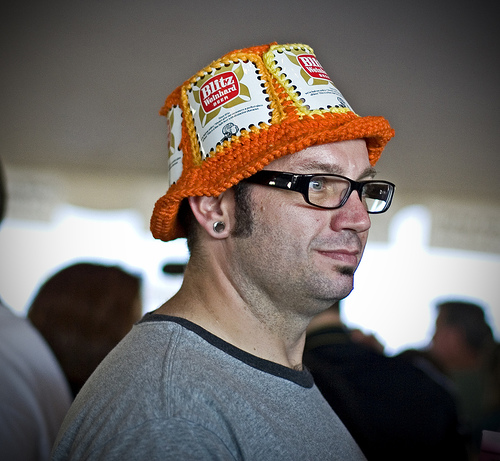

Captions for 1007129816_e794419615.jpg:
- A man in an orange hat starring at something .
- A man wears an orange hat and glasses .
- A man with gauges and glasses is wearing a Blitz hat .
- A man with glasses is wearing a beer can crocheted hat .
- The man with pierced ears is wearing glasses and an orange hat .


In [4]:
import os
import pandas as pd
from IPython.display import Image, display

# Get the path to the images directory
image_dir = os.path.join(path, 'Images')
captions_path = os.path.join(path, 'captions.txt')

# Load the captions
captions_df = pd.read_csv(captions_path)

# List the image files
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

# Display a few sample images with captions
num_samples = 5
print(f"Displaying {num_samples} sample images with captions:")

unique_image_names = captions_df['image'].unique()

for i in range(min(num_samples, len(unique_image_names))):
    image_name = unique_image_names[i]
    image_path = os.path.join(image_dir, image_name)

    image_captions = captions_df[captions_df['image'] == image_name]['caption'].tolist()

    display(Image(filename=image_path))
    print(f"Captions for {image_name}:")
    for caption in image_captions:
        print(f"- {caption}")

In [5]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /usr/share/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
print("Columns:", captions_df.columns)
print("Shape:", captions_df.shape)

Columns: Index(['image', 'caption'], dtype='object')
Shape: (40455, 2)


#Text Preprocessing

In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

captions_df['clean_caption'] = captions_df['caption'].apply(clean_text)

In [8]:
captions_df['clean_caption'][:][:5000]

0       a child in a pink dress is climbing up a set o...
1                     a girl going into a wooden building
2          a little girl climbing into a wooden playhouse
3       a little girl climbing the stairs to her playh...
4       a little girl in a pink dress going into a woo...
                              ...                        
4995    a brown chow mix dog is standing in front of a...
4996                 a brown dog standing in a muddy yard
4997    a brown dogs walks near a green van and some junk
4998    a large brown dog stands in front of a green v...
4999    a yellow dog is standing in front of a green c...
Name: clean_caption, Length: 5000, dtype: object

#Tokenization

In [9]:
from nltk.tokenize import sent_tokenize, word_tokenize

sample_text = captions_df['clean_caption'][0]

sentences_nltk = sent_tokenize(sample_text)
words_nltk = word_tokenize(sample_text)

print("NLTK Sentences:", sentences_nltk[:3])
print("NLTK Words:", words_nltk[:20])

NLTK Sentences: ['a child in a pink dress is climbing up a set of stairs in an entry way']
NLTK Words: ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way']


In [10]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp(sample_text)
sentences_spacy = [sent.text for sent in doc.sents]
tokens_spacy = [token.text for token in doc]

print("spaCy Sentences:", sentences_spacy[:3])
print("spaCy Tokens:", tokens_spacy[:20])

spaCy Sentences: ['a child in a pink dress is climbing up a set of stairs in an entry way']
spaCy Tokens: ['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way']


#Stopwords

In [11]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

filtered_nltk = [w.lower() for w in words_nltk if w.lower() not in stop_words and w.isalpha()]
filtered_nltk

['child', 'pink', 'dress', 'climbing', 'set', 'stairs', 'entry', 'way']

In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

num_samples_to_show = 3
for i in range(num_samples_to_show):
    sample_text = captions_df['clean_caption'][i+1]
    words_nltk = nltk.word_tokenize(sample_text)
    filtered_nltk = [w.lower() for w in words_nltk if w.lower() not in stop_words and w.isalpha()]

    print(f"Original Caption {i+1}: {sample_text}")
    print(f"Filtered Caption {i+1}: {filtered_nltk}")

Original Caption 1: a girl going into a wooden building
Filtered Caption 1: ['girl', 'going', 'wooden', 'building']
Original Caption 2: a little girl climbing into a wooden playhouse
Filtered Caption 2: ['little', 'girl', 'climbing', 'wooden', 'playhouse']
Original Caption 3: a little girl climbing the stairs to her playhouse
Filtered Caption 3: ['little', 'girl', 'climbing', 'stairs', 'playhouse']


# Lemmatization

In [13]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp(sample_text)

In [14]:
filtered_spacy = [token.lemma_.lower() for token in doc if not token.is_stop and token.is_alpha]
filtered_spacy

['little', 'girl', 'climb', 'stair', 'playhouse']

#Explore & Analyze

In [15]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Calculate text length statistics
captions_df['caption_length'] = captions_df['clean_caption'].apply(len)
print("Text Length Statistics:")
print(captions_df['caption_length'].describe())

Text Length Statistics:
count    40455.000000
mean        53.111383
std         18.593182
min          1.000000
25%         40.000000
50%         51.000000
75%         64.000000
max        194.000000
Name: caption_length, dtype: float64


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


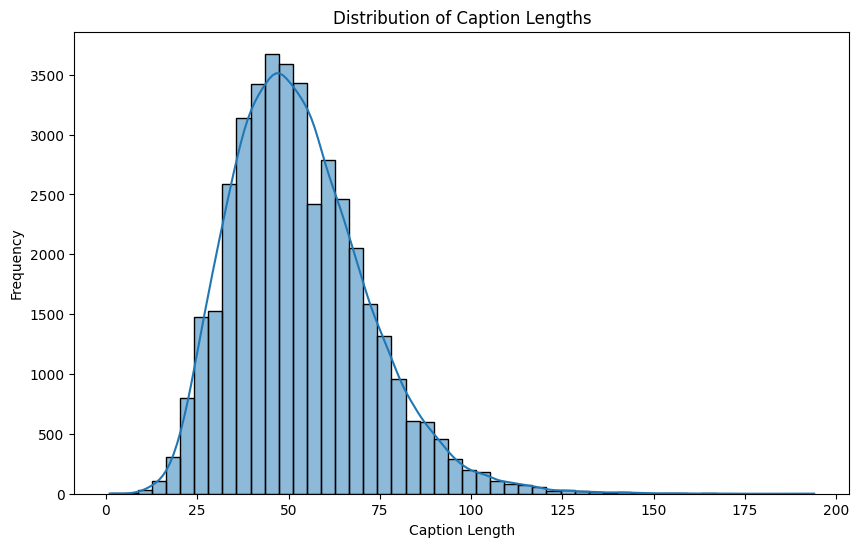

In [17]:
# Visualize text length distribution
plt.figure(figsize=(10, 6))
sns.histplot(captions_df['caption_length'], bins=50, kde=True)
plt.title('Distribution of Caption Lengths')
plt.xlabel('Caption Length')
plt.ylabel('Frequency')
plt.show()

In [18]:
# Get all words from the cleaned captions
all_words = ' '.join(captions_df['clean_caption']).split()

# Get the most common words
word_counts = Counter(all_words)
most_common_words = word_counts.most_common(20) # Get top 20

print("\nMost Common Words (Top 20):")
for word, count in most_common_words:
    print(f"{word}: {count}")


Most Common Words (Top 20):
a: 62986
in: 18974
the: 18418
on: 10743
is: 9345
and: 8851
dog: 8136
with: 7765
man: 7265
of: 6713
two: 5638
white: 3940
black: 3832
boy: 3581
are: 3504
woman: 3402
girl: 3328
to: 3173
wearing: 3062
at: 2914


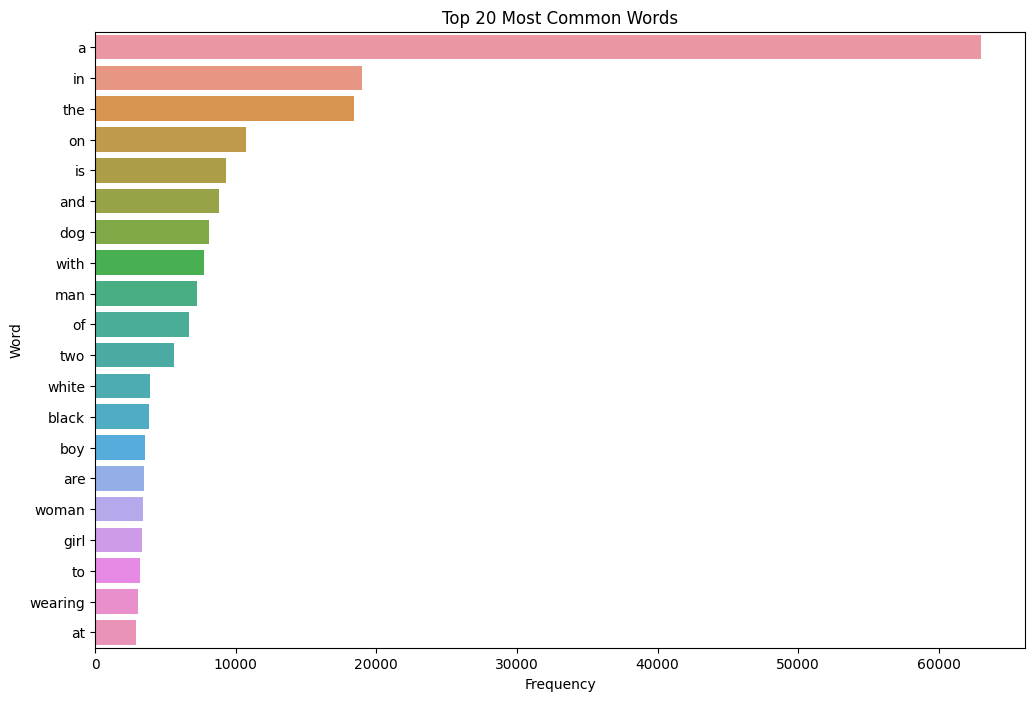

In [19]:
most_common_df = pd.DataFrame(most_common_words, columns=['word', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='word', data=most_common_df)
plt.title('Top 20 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

#TF-IDF

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.95)

tfidf_matrix = tfidf_vectorizer.fit_transform(captions_df['clean_caption'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
print("TF-IDF feature names (sample):", tfidf_feature_names[:20])

TF-IDF matrix shape: (40455, 2977)
TF-IDF feature names (sample): ['23' 'abandoned' 'about' 'above' 'accordion' 'acrobatic' 'across' 'act'
 'acting' 'action' 'active' 'adjusting' 'adult' 'adults' 'advertisement'
 'advertising' 'aerial' 'african' 'africanamerican' 'after']


# Skip-Gram

In [21]:
!pip install gensim

In [22]:
from gensim.models import Word2Vec
import nltk

tokenized_captions = [nltk.word_tokenize(caption) for caption in captions_df['clean_caption']]

w2v_model_skip = Word2Vec(
    sentences=tokenized_captions[:2000],
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,      # skip-gram
    epochs=10
)


In [23]:
print(w2v_model_skip.wv.most_similar('boy'))
print(w2v_model_skip.wv.most_similar('girl'))

[('little', 0.962975025177002), ('girl', 0.9603808522224426), ('child', 0.9526377320289612), ('jacket', 0.9349932670593262), ('rides', 0.9314651489257812), ('life', 0.9275255799293518), ('holding', 0.9240154027938843), ('helmet', 0.9199503064155579), ('vest', 0.9196972846984863), ('dress', 0.9178373217582703)]
[('dress', 0.9749135971069336), ('little', 0.9657774567604065), ('jacket', 0.9643356204032898), ('pink', 0.9627788662910461), ('helmet', 0.9613611102104187), ('boy', 0.9603809118270874), ('blue', 0.9587963223457336), ('striped', 0.9571254849433899), ('rides', 0.9531639218330383), ('holding', 0.9526647925376892)]


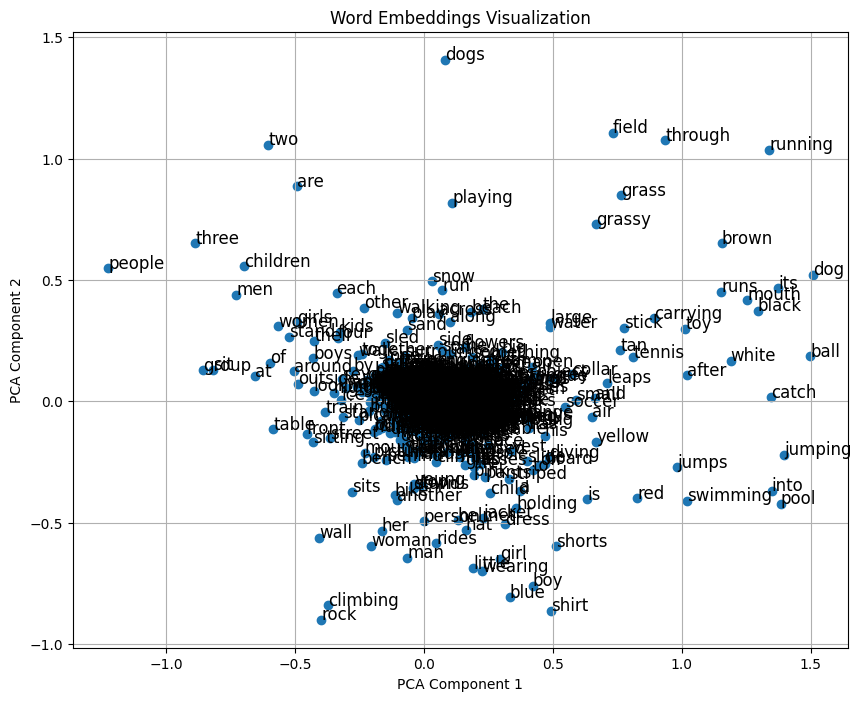

In [24]:
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

word_vectors = w2v_model_skip.wv[w2v_model_skip.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])

words = list(w2v_model_skip.wv.index_to_key)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

plt.title("Word Embeddings Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

#Image Feature Extraction

In [25]:
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os
from tqdm import tqdm

cnn = DenseNet201(weights="imagenet", include_top=False, pooling="avg")

img_size = 224
features = {}

for image in tqdm(captions_df["image"].unique().tolist()):
    img = load_img(os.path.join(image_dir, image), target_size=(img_size, img_size))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    feature = cnn.predict(x, verbose=0)
    features[image] = feature


2025-12-27 15:27:27.792156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766849247.984480      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766849248.040572      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

I0000 00:00:1766849258.132251      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766849258.132855      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


  0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1766849269.441295     169 service.cc:148] XLA service 0x7836f8007250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766849269.442113     169 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766849269.442131     169 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766849271.559141     169 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1766849283.912934     169 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8091/8091 [13:47<00:00,  9.77it/s]


#Data Generation

In [26]:
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer

class CustomDataGenerator(Sequence):
    def __init__(self ,
                 df,
                 X_col ,
                 y_col ,
                 batch_size ,
                 directory ,
                 tokenizer ,
                 vocab_size ,
                 max_length ,
                 features ,
                 shuffle=True):

        self.df = df.copy()
        self.X_col = X_col
        self.y_col = y_col
        self.directory = directory
        self.batch_size =batch_size
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.features = features
        self.vocab_size = vocab_size
        self.shuffle = shuffle
        self.n = len(self.df)

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop = True)

    def __len__(self):
        return self.n // self.batch_size

    def __getitem__(self , index):
        batch = self.df.iloc[index * self.batch_size : (index +1) * self.batch_size,:]
        X1 , X2 , y = self.__get_data(batch)
        return (X1 , X2) , y


    def __get_data(self , batch):
        X1,X2,y = list(),list(),list()
        images = batch[self.X_col].tolist()

        for image in images:
            feature = self.features[image][0]

            captions = batch.loc[batch[self.X_col]==image , self.y_col].tolist()
            for caption in captions:
                seq = self.tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length, padding="post")[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

        X1 , X2 , y = np.array(X1) , np.array(X2) , np.array(y)
        return X1 , X2 , y

# Prepare tokenizer
tokenizer = Tokenizer()
captions_df["clean_caption"] = captions_df["clean_caption"].apply(
    lambda x: "startseq " + x.strip() + " endseq")
tokenizer.fit_on_texts(captions_df['clean_caption'])
vocab_size = len(tokenizer.word_index) + 1

# Determine max_length
max_length = max(len(seq.split()) for seq in captions_df['clean_caption'])

# Split data into train and test sets
unique_images = captions_df["image"].unique()
train_imgs, test_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)

train = captions_df[captions_df["image"].isin(train_imgs)].reset_index(drop=True)
test  = captions_df[captions_df["image"].isin(test_imgs)].reset_index(drop=True)
train_generator = CustomDataGenerator(df = train , X_col = "image" , y_col = "clean_caption" , batch_size = 64 , directory = image_dir ,                                  tokenizer = tokenizer , vocab_size = vocab_size , max_length = max_length , features = features)

validation_generator = CustomDataGenerator(df = test , X_col = "image" , y_col = "clean_caption" , batch_size = 64 , directory = image_dir,
                                          tokenizer = tokenizer , vocab_size = vocab_size , max_length = max_length , features = features)

In [27]:
# sit row train_generator
train_generator[0]

((array([[8.4153078e-05, 5.7382404e-04, 1.0144026e-03, ..., 4.4887596e-01,
          1.5173441e-01, 1.1663274e+00],
         [8.4153078e-05, 5.7382404e-04, 1.0144026e-03, ..., 4.4887596e-01,
          1.5173441e-01, 1.1663274e+00],
         [8.4153078e-05, 5.7382404e-04, 1.0144026e-03, ..., 4.4887596e-01,
          1.5173441e-01, 1.1663274e+00],
         ...,
         [1.7417883e-04, 5.3456501e-04, 1.3675566e-03, ..., 0.0000000e+00,
          1.5397646e+00, 1.4775640e+00],
         [1.7417883e-04, 5.3456501e-04, 1.3675566e-03, ..., 0.0000000e+00,
          1.5397646e+00, 1.4775640e+00],
         [1.7417883e-04, 5.3456501e-04, 1.3675566e-03, ..., 0.0000000e+00,
          1.5397646e+00, 1.4775640e+00]], dtype=float32),
  array([[   2,    0,    0, ...,    0,    0,    0],
         [   2,    1,    0, ...,    0,    0,    0],
         [   2,    1,   42, ...,    0,    0,    0],
         ...,
         [   2,  954, 1043, ...,    0,    0,    0],
         [   2,  954, 1043, ...,    0,    0,    0],

#LSTM

In [28]:
# LSTM MODEL
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, add
from tensorflow.keras.models import Model

# Branch 1: Image feature vector (DenseNet)
inputs1 = Input(shape=(1920,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Branch 2: Caption input sequence
inputs2 = Input(shape=(max_length,))
# mask_zero=False avoids mask creation → NO cuDNN mask conflicts
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(
    256,
    dropout=0.2,
    recurrent_dropout=0.2,
    return_sequences=False,
    use_cudnn=False   # extra safety
)(se2)

# Decoder — merge visual + language features
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)

# Output vocab distribution
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Build model
stable_lstm_model = Model(inputs=[inputs1, inputs2], outputs=outputs)
stable_lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1920)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,736 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1920)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 38, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    491,776 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8831)      │  2,269,567 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,613,183 (21.41 MB)

 Trainable params: 5,613,183 (21.41 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
stable_lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("best_lstm_model.keras", monitor="val_loss", save_best_only=True)
stable_lstm_model.fit(train_generator, validation_data=validation_generator, epochs=40, callbacks=[checkpoint])

from tensorflow.keras.models import load_model
lstm_model = load_model("best_lstm_model.keras", compile=False)

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


505/505 ━━━━━━━━━━━━━━━━━━━━ 1136s 2s/step - loss: 4.9994 - val_loss: 3.5453
Epoch 2/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 160s 317ms/step - loss: 3.3576 - val_loss: 3.2746
Epoch 3/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 159s 316ms/step - loss: 3.0189 - val_loss: 3.1816
Epoch 4/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 87s 173ms/step - loss: 2.8099 - val_loss: 3.1603
Epoch 5/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 63s 126ms/step - loss: 2.6671 - val_loss: 3.1427
Epoch 6/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 83s 163ms/step - loss: 2.5460 - val_loss: 3.1672
Epoch 7/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 102s 202ms/step - loss: 2.4458 - val_loss: 3.1848
Epoch 8/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - loss: 2.3663 - val_loss: 3.2303
Epoch 9/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 79s 157ms/step - loss: 2.2973 - val_loss: 3.2541
Epoch 10/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 47s 92ms/step - loss: 2.2417 - val_loss: 3.2908
Epoch 11/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 82s 162ms/step - loss: 2.1979 - val_loss: 3.3071
Epoch 12/40
505/505 ━━━━━━━━━

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input
import matplotlib.pyplot as plt

def generate_desc_debug(model, tokenizer, photo, max_length):
    # build reverse map once
    index_word = {v: k for k, v in tokenizer.word_index.items()}

    in_text = "startseq"
    print(" DEBUG START")
    print("Initial in_text:", in_text)

    for step in range(max_length):
        print(f"STEP {step + 1}")
        print("in_text =", in_text)

        sequence = tokenizer.texts_to_sequences([in_text])[0]
        print("sequence =", sequence)

        if len(sequence) == 0:
            print(" EMPTY sequence! Fixing.")
            sequence = [tokenizer.word_index["startseq"]]

        sequence = pad_sequences([sequence], maxlen=max_length, padding="post")
        print("sequence (padded) =", sequence)

        yhat = model.predict([photo, sequence], verbose=0)[0]
        yhat = int(np.argmax(yhat))
        print("Predicted token id (yhat) =", yhat)

        word = index_word.get(yhat)
        print("Predicted word =", word)

        if word is None:
            print(" ERROR: Token ID not in vocabulary")
            break

        in_text += " " + word

        if word == "endseq":
            print("END TOKEN reached")
            break

    print(" DEBUG END ")
    return in_text.replace("startseq", "").replace("endseq", "").strip()



def predict_caption(image_path, model, tokenizer):
    print(" PREDICT CAPTION DEBUG ")
    print("Image:", image_path)

    img = load_img(image_path, target_size=(224,224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # cnn is your DenseNet201(include_top=False, pooling="avg")
    feature = cnn.predict(x, verbose=0)     # shape (1,1920)
    print("Feature shape:", feature.shape)

    caption = generate_desc_debug(model, tokenizer, feature, max_length)

    print("\nPredicted Caption:", caption)
    plt.imshow(load_img(image_path))
    plt.axis("off")
    return caption


#RNN

In [32]:
from tensorflow.keras.layers import Input, Dense, Embedding, SimpleRNN, Dropout, add
from tensorflow.keras.models import Model

# Feature extractor branch
inputs1 = Input(shape=(1920,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence input branch
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = SimpleRNN(256)(se2)

# Combine branches
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Build model
rnn_model = Model(inputs=[inputs1, inputs2], outputs=outputs)
rnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 1920)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 38, 256)   │  2,260,736 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1920)      │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 38, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 38)        │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    491,776 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 256)       │    131,328 │ dropout_3[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8831)      │  2,269,567 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,219,199 (19.91 MB)

 Trainable params: 5,219,199 (19.91 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [34]:
checkpoint = ModelCheckpoint("best_rnn_model.keras", monitor="val_loss", save_best_only=True, verbose=1)

history = rnn_model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/40
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - loss: 4.8520
Epoch 1: val_loss improved from inf to 3.49052, saving model to best_rnn_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 398s 780ms/step - loss: 4.8491 - val_loss: 3.4905
Epoch 2/40
503/505 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 3.3046
Epoch 2: val_loss improved from 3.49052 to 3.26298, saving model to best_rnn_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 76s 150ms/step - loss: 3.3042 - val_loss: 3.2630
Epoch 3/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 2.9778
Epoch 3: val_loss improved from 3.26298 to 3.19654, saving model to best_rnn_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - loss: 2.9777 - val_loss: 3.1965
Epoch 4/40
503/505 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 2.7798
Epoch 4: val_loss improved from 3.19654 to 3.19195, saving model to best_rnn_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - loss: 2.7798 - val_loss: 3.1920
Epoch 5/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 

In [35]:
from tensorflow.keras.applications.densenet import preprocess_input

def predict_caption_rnn(image_path, model, tokenizer):
    img = load_img(image_path, target_size=(224,224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    feature = cnn.predict(x, verbose=0)
    caption = generate_desc_debug(model, tokenizer, feature, max_length)

    print("Predicted Caption:", caption)
    plt.imshow(load_img(image_path))
    plt.axis('off')
    return caption

#GRU

In [36]:
from tensorflow.keras.layers import Input, Dense, Embedding, GRU, Dropout, add
from tensorflow.keras.models import Model

# Feature extractor branch (DenseNet features)
inputs1 = Input(shape=(1920,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence input branch (Caption tokens)
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.5)(se1)

# GRU layer
se3 = GRU(256)(se2)

# Combine branches
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Build GRU model
gru_model = Model(inputs=[inputs1, inputs2], outputs=outputs)
gru_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 1920)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 38, 256)   │  2,260,736 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 1920)      │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 38, 256)   │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 38)        │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    491,776 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 256)       │    394,752 │ dropout_5[0][0],  │
│                     │                   │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ dense_6[0][0],    │
│                     │                   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8831)      │  2,269,567 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,482,623 (20.91 MB)

 Trainable params: 5,482,623 (20.91 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')

In [38]:
checkpoint = ModelCheckpoint("best_gru_model.keras", monitor="val_loss", save_best_only=True, verbose=1)

history = gru_model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/40
505/505 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 4.8666
Epoch 1: val_loss improved from inf to 3.44772, saving model to best_gru_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - loss: 4.8651 - val_loss: 3.4477
Epoch 2/40
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.2582
Epoch 2: val_loss improved from 3.44772 to 3.23398, saving model to best_gru_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - loss: 3.2579 - val_loss: 3.2340
Epoch 3/40
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.9345
Epoch 3: val_loss improved from 3.23398 to 3.15538, saving model to best_gru_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - loss: 2.9344 - val_loss: 3.1554
Epoch 4/40
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.7283
Epoch 4: val_loss improved from 3.15538 to 3.14893, saving model to best_gru_model.keras
505/505 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - loss: 2.7282 - val_loss: 3.1489
Epoch 5/40
504/505 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.5750


In [39]:
def predict_caption_gru(image_path, model, tokenizer):
    img = load_img(image_path, target_size=(224,224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    feature = cnn.predict(x, verbose=0)
    caption = generate_desc_debug(model, tokenizer, feature, max_length)

    print("Predicted Caption:", caption)
    plt.imshow(load_img(image_path))
    plt.axis('off')
    return caption

# Evaluation, Metrics, and Comparison


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, GRU, SimpleRNN, Dropout, add
from tensorflow.keras.models import Model
import pandas as pd
from tqdm import tqdm
import warnings
from tensorflow.keras.preprocessing.sequence import pad_sequences
warnings.filterwarnings('ignore')

In [41]:
def strip_tokens(tokens):
    return [t for t in tokens if t not in ("startseq", "endseq")]

In [42]:
from tensorflow.keras.models import load_model

# Load LSTM model
lstm_model = load_model("best_lstm_model.keras")
print("LSTM model loaded.")

# Load RNN model
rnn_model = load_model("best_rnn_model.keras")
print("RNN model loaded.")

# Load GRU model
gru_model = load_model("best_gru_model.keras")
print("GRU model loaded.")

LSTM model loaded.
RNN model loaded.
GRU model loaded.


In [43]:
# #greedy
# def generate_caption(model, tokenizer, photo, max_length):
#     index_word = {v: k for k, v in tokenizer.word_index.items()}

#     in_text = "startseq"
#     for _ in range(max_length):
#         seq = tokenizer.texts_to_sequences([in_text])[0]
#         seq = pad_sequences([seq], maxlen=max_length, padding="post")

#         yhat = model.predict([photo, seq], verbose=0)[0]
#         yhat = int(np.argmax(yhat))

#         word = index_word.get(yhat)
#         if word is None:
#             break

#         in_text += " " + word
#         if word == "endseq":
#             break

#     # remove start/end before returning
#     return " ".join([w for w in in_text.split() if w not in ("startseq", "endseq")])

#beam
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_caption(model, tokenizer, photo, max_length, beam_size=5):
    # reverse map for fast id->word
    index_word = {v: k for k, v in tokenizer.word_index.items()}

    start = tokenizer.word_index.get("startseq")
    end = tokenizer.word_index.get("endseq")

    # (sequence_of_token_ids, log_prob)
    sequences = [([start], 0.0)]

    for _ in range(max_length):
        all_candidates = []

        for seq, score in sequences:
            # if already ended, keep it
            if end is not None and seq[-1] == end:
                all_candidates.append((seq, score))
                continue

            seq_padded = pad_sequences([seq], maxlen=max_length, padding="post")
            yhat = model.predict([photo, seq_padded], verbose=0)[0]

            # top beam_size tokens
            top_k = np.argsort(yhat)[-beam_size:]
            for tok in top_k:
                prob = float(yhat[tok])
                cand = (seq + [int(tok)], score + np.log(prob + 1e-12))
                all_candidates.append(cand)

        # keep best beam_size sequences
        sequences = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_size]

    # best sequence
    best_seq = sequences[0][0]

    # convert to words, remove start/end
    words = []
    for tok in best_seq:
        w = index_word.get(tok)
        if w is None or w == "startseq":
            continue
        if w == "endseq":
            break
        words.append(w)

    return " ".join(words)


In [44]:
def get_photo(features, image_name):
    photo = features[image_name]
    # make sure it's shape (1, 1920) for model.predict
    if isinstance(photo, np.ndarray) and photo.ndim == 1:     # (1920,)
        photo = photo.reshape(1, -1)                          # (1,1920)
    return photo

In [45]:
def generate_word_level_predictions(model, test_df, features, tokenizer, max_length, model_name):
    all_true_labels = []
    all_pred_labels = []

    print(f"Generating predictions with {model_name}")

    sample_size = min(500, len(test_df))
    test_sample = test_df.sample(n=sample_size, random_state=42)

    for _, row in tqdm(test_sample.iterrows(), total=len(test_sample), desc=f"{model_name}"):
        image_name = row["image"]
        caption = row["clean_caption"]

        photo = get_photo(features, image_name)

        seq = tokenizer.texts_to_sequences([caption])[0]

        for i in range(1, min(len(seq), max_length)):
            in_seq = seq[:i]
            out_word = seq[i]

            in_seq_padded = pad_sequences([in_seq], maxlen=max_length, padding="post")
            yhat = model.predict([photo, in_seq_padded], verbose=0)[0]
            pred_word = int(np.argmax(yhat))

            all_true_labels.append(out_word)
            all_pred_labels.append(pred_word)

    return np.array(all_true_labels), np.array(all_pred_labels)


# Generate word-level predictions for all models
print(" Evaluating LSTM")
lstm_true, lstm_pred = generate_word_level_predictions(
    lstm_model, test, features, tokenizer, max_length, "LSTM"
)

print(" Evaluating RNN")
rnn_true, rnn_pred = generate_word_level_predictions(
    rnn_model, test, features, tokenizer, max_length, "RNN"
)

print(" Evaluating GRU")
gru_true, gru_pred = generate_word_level_predictions(
    gru_model, test, features, tokenizer, max_length, "GRU"
)

 Evaluating LSTM
Generating predictions with LSTM


LSTM: 100%|██████████| 500/500 [09:07<00:00,  1.10s/it]


 Evaluating RNN
Generating predictions with RNN


RNN: 100%|██████████| 500/500 [07:10<00:00,  1.16it/s]


 Evaluating GRU
Generating predictions with GRU


GRU: 100%|██████████| 500/500 [07:14<00:00,  1.15it/s]


In [46]:
def evaluate_bleu_scores(model, tokenizer, test_df, features, max_length, model_name, sample_size=200):
    smoothie = SmoothingFunction().method4
    bleu1_scores, bleu2_scores, bleu3_scores = [], [], []

    test_sample = test_df.sample(n=min(sample_size, len(test_df)), random_state=42)

    print(f"\nEvaluating BLEU scores for {model_name}")

    for image_name in tqdm(test_sample["image"].unique(), desc=model_name):
        # references (strip start/end)
        refs = test_df[test_df["image"] == image_name]["clean_caption"].tolist()
        references = [strip_tokens(r.split()) for r in refs]

        photo = get_photo(features, image_name)
        predicted_caption = generate_caption(model, tokenizer, photo, max_length)
        candidate = strip_tokens(predicted_caption.split())

        if len(candidate) == 0:
            continue

        bleu1_scores.append(sentence_bleu(references, candidate, weights=(1, 0, 0, 0), smoothing_function=smoothie))
        bleu2_scores.append(sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie))
        bleu3_scores.append(sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smoothie))

    return {
        "Model": model_name,
        "BLEU-1": float(np.mean(bleu1_scores)) if bleu1_scores else 0.0,
        "BLEU-2": float(np.mean(bleu2_scores)) if bleu2_scores else 0.0,
        "BLEU-3": float(np.mean(bleu3_scores)) if bleu3_scores else 0.0,
    }


In [47]:
lstm_bleu = evaluate_bleu_scores(
    lstm_model, tokenizer, test, features, max_length, "LSTM"
)

rnn_bleu = evaluate_bleu_scores(
    rnn_model, tokenizer, test, features, max_length, "RNN"
)

gru_bleu = evaluate_bleu_scores(
    gru_model, tokenizer, test, features, max_length, "GRU"
)



Evaluating BLEU scores for LSTM


LSTM: 100%|██████████| 190/190 [18:58<00:00,  5.99s/it]



Evaluating BLEU scores for RNN


RNN: 100%|██████████| 190/190 [13:19<00:00,  4.21s/it]



Evaluating BLEU scores for GRU


GRU: 100%|██████████| 190/190 [14:32<00:00,  4.59s/it]


In [48]:
bleu_results_df = pd.DataFrame([lstm_bleu, rnn_bleu, gru_bleu])

print("\n BLEU Score Comparison:")
print(bleu_results_df.to_string(index=False))



 BLEU Score Comparison:
Model   BLEU-1   BLEU-2   BLEU-3
 LSTM 0.600185 0.405153 0.277143
  RNN 0.578504 0.378368 0.248199
  GRU 0.597615 0.389587 0.271877


# Performance Comparison

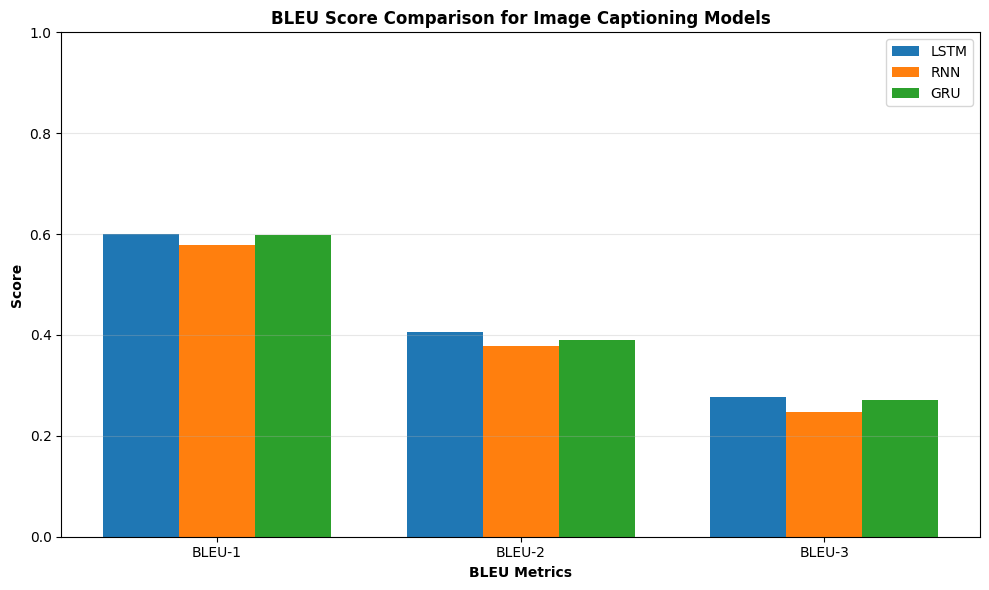

In [49]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3']
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, bleu_results_df.loc[0, metrics], width, label='LSTM')
plt.bar(x,         bleu_results_df.loc[1, metrics], width, label='RNN')
plt.bar(x + width, bleu_results_df.loc[2, metrics], width, label='GRU')

plt.xlabel('BLEU Metrics', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.title('BLEU Score Comparison for Image Captioning Models', fontweight='bold')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bleu_score_comparison.png', dpi=300)
plt.show()


# Captions Visualization

In [50]:
import random
sample_images = random.sample(test["image"].unique().tolist(), k=6)
lstm_samples, rnn_samples, gru_samples = {}, {}, {}

# generate captions for each selected image
for img_name in sample_images:
    photo = get_photo(features, img_name)   # makes shape (1,1920)

    lstm_samples[img_name] = generate_caption(lstm_model, tokenizer, photo, max_length)
    rnn_samples[img_name]  = generate_caption(rnn_model, tokenizer, photo, max_length)
    gru_samples[img_name]  = generate_caption(gru_model, tokenizer, photo, max_length)

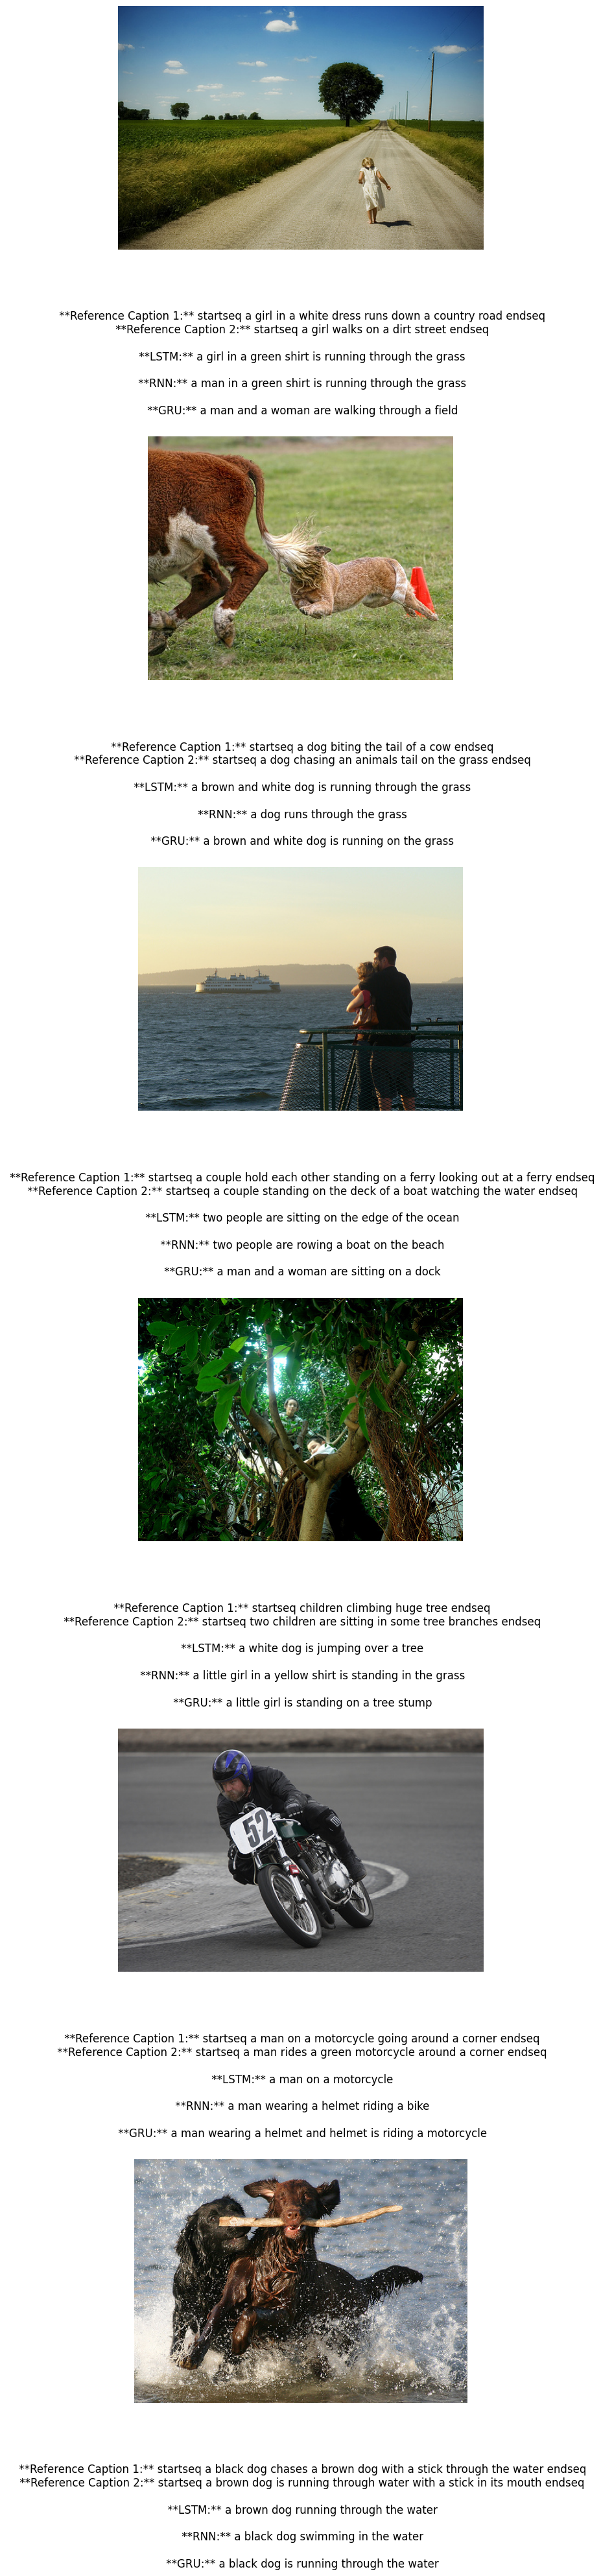

In [51]:
# Sample predictions
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Visualize samples clearly
fig, axes = plt.subplots(6, 1, figsize=(15, 40))

for idx, image_name in enumerate(sample_images):
    ax = axes[idx]

    # Load the image
    img_path = os.path.join(image_dir, image_name)
    img = plt.imread(img_path)

    # Show image
    ax.imshow(img)
    ax.axis('off')

    # Get reference captions (max 2)
    ref_caps = test[test['image'] == image_name]['clean_caption'].tolist()[:2]

    # Clean written text area
    caption_text = (
        f" **Reference Caption 1:** {ref_caps[0]}\n"
        f" **Reference Caption 2:** {ref_caps[1] if len(ref_caps) > 1 else 'N/A'}\n\n"
        f" **LSTM:** {lstm_samples[image_name]}\n\n"
        f" **RNN:** {rnn_samples[image_name]}\n\n"
        f" **GRU:** {gru_samples[image_name]}"
    )

    # Add text BELOW image
    ax.text(
        0.5, -0.25, caption_text,
        transform=ax.transAxes,
        fontsize=12,
        va='top', ha='center',
        wrap=True
    )

plt.tight_layout()
plt.savefig('sample_predictions_clean.png', dpi=300, bbox_inches='tight')
plt.show()

In [54]:
stable_lstm_model.save("/kaggle/working/artifacts/last_lstm_model.keras")
rnn_model.save("/kaggle/working/artifacts/last_rnn_model.keras")
gru_model.save("/kaggle/working/artifacts/last_gru_model.keras")


In [55]:
!ls -lh /kaggle/working/artifacts

total 188M
-rw-r--r-- 1 root root   38 Dec 27 18:35 config.json
-rw-r--r-- 1 root root  63M Dec 27 18:37 last_gru_model.keras
-rw-r--r-- 1 root root  65M Dec 27 18:37 last_lstm_model.keras
-rw-r--r-- 1 root root  60M Dec 27 18:37 last_rnn_model.keras
-rw-r--r-- 1 root root 750K Dec 27 18:35 tokenizer.json


In [56]:
from tensorflow.keras.models import load_model

lstm = load_model("/kaggle/working/artifacts/last_lstm_model.keras", compile=False)
rnn  = load_model("/kaggle/working/artifacts/last_rnn_model.keras", compile=False)
gru  = load_model("/kaggle/working/artifacts/last_gru_model.keras", compile=False)

print("All models load OK ✅")

All models load OK ✅


In [57]:
!ls -lh /kaggle/working/artifacts

total 188M
-rw-r--r-- 1 root root   38 Dec 27 18:35 config.json
-rw-r--r-- 1 root root  63M Dec 27 18:37 last_gru_model.keras
-rw-r--r-- 1 root root  65M Dec 27 18:37 last_lstm_model.keras
-rw-r--r-- 1 root root  60M Dec 27 18:37 last_rnn_model.keras
-rw-r--r-- 1 root root 750K Dec 27 18:35 tokenizer.json


In [58]:
!cd /kaggle/working && zip -r artifacts.zip artifacts

  adding: artifacts/ (stored 0%)
  adding: artifacts/last_gru_model.keras (deflated 9%)
  adding: artifacts/last_rnn_model.keras (deflated 10%)
  adding: artifacts/tokenizer.json (deflated 69%)
  adding: artifacts/config.json (stored 0%)
  adding: artifacts/last_lstm_model.keras (deflated 10%)


In [59]:
import tensorflow as tf; tf.__version__

'2.18.0'